In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [4]:
df = pd.read_csv("/content/feature_engineered_data.csv")

In [5]:
df.head(4)

,date,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours,year,month,day,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,2022-01-31,0,29.7,46,14.24,5,1,1.30,2022,1,31,0,0,24.17,25.48,26.65,23.034286,22.247333
1,2022-02-01,3,31.7,39,25.43,3,2,1.22,2022,2,1,1,0,14.24,17.76,25.32,24.130000,22.251000
2,2022-02-02,3,28.3,79,24.70,4,2,2.02,2022,2,2,2,0,25.43,27.13,23.40,23.782857,22.294333
3,2022-02-03,1,32.5,56,10.78,8,0,1.04,2022,2,3,3,0,24.70,31.90,20.51,20.765714,21.970000


In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['electricity_units_kwh']])

In [7]:
sequence_length = 30
X=[]
y=[]

for i in range(sequence_length, len(scaled_data)):
  X.append(scaled_data[i-sequence_length:i])
  y.append(scaled_data[i])
X=np.array(X)
y=np.array(y)

In [8]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [9]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer = 'adam',
    loss = 'mean_squared_error'
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0513 - val_loss: 0.0259
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0305 - val_loss: 0.0233
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0297 - val_loss: 0.0253
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0301 - val_loss: 0.0231
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0304 - val_loss: 0.0231
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0303 - val_loss: 0.0237
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0293 - val_loss: 0.0230
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0300 - val_loss: 0.0230
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0295 - val_loss: 0.0247
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0305 - val_loss: 0.0229
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0307 - val_loss: 0.0229
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0

In [12]:
predictions = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [13]:
predictions = scaler.inverse_transform(predictions)

y_test = scaler.inverse_transform(y_test)

In [14]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 4.709751853942872
MSE : 32.747310298879405
RMSE: 5.722526566026532


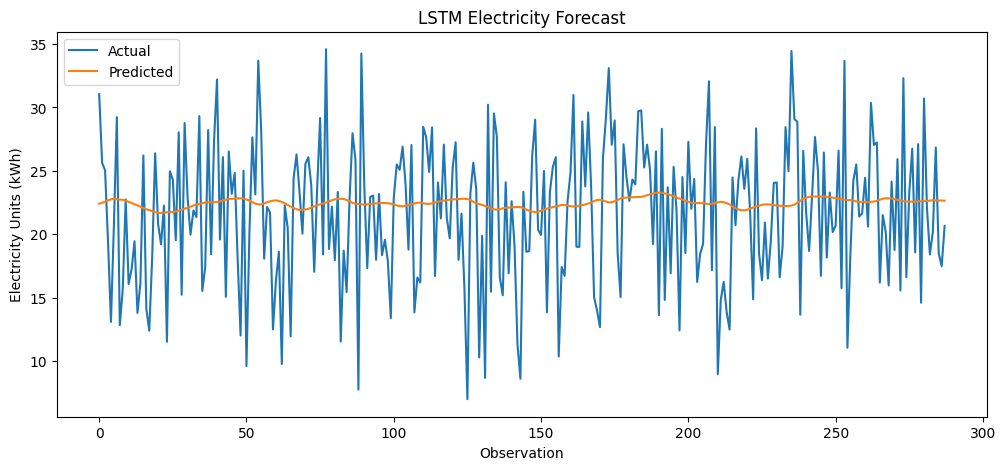

In [15]:
plt.figure(figsize=(12,5))

plt.plot(y_test, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("LSTM Electricity Forecast")
plt.xlabel("Observation")
plt.ylabel("Electricity Units (kWh)")
plt.legend()

plt.show()

In [16]:
results = pd.DataFrame({
    "Model": ["LSTM"],
    "MAE": [mae],
    "MSE": [mse],
    "RMSE": [rmse]
})

results.to_csv("lstm_results.csv", index=False)

In [17]:
model.save("lstm.keras")

In [18]:
from google.colab import files

files.download("lstm.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>